### Purpose

This notebook performs a full exploratory and analytical analysis to evaluate whether proximity to Saltwater Injection Wells (SWIWs) affects oil and gas well production in Ohio. Using geospatial processing, the notebook converts well locations into GeoDataFrames and employs a KD-Tree with haversine geometry to efficiently compute the nearest SWIW for every production well, exporting those distances for further analysis. The workflow includes visualizations such as distance distributions and a map showing wells colored by proximity to the nearest SWIW. Building on the spatial results, the notebook performs multiple regression approaches, including basic OLS, cluster-robust specifications, and a generalized additive model (GAM), to evaluate whether SWIW proximity is associated with variations in oil and gas production. The analysis concludes with diagnostic plots and partial-effect visualizations to characterize potential nonlinear or time-varying relationships.

### Load Libraries

In [6]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
import geopandas as gpd
from shapely.geometry import Point
from tqdm import tqdm

### Load Data

In [14]:
well_info = pd.read_csv('../data/final/well_information_final.csv')
permits = pd.read_csv('../data/final/permit_plug_list_final.csv')

### Create GeoDataFrames for each dataset

In [ ]:
well_info = well_info.dropna(subset=['WELL LATITUDE', 'WELL LONGITUDE'])
permits = permits.dropna(subset=['WH_LAT', 'WH_LONG'])

# well_gdf = gpd.GeoDataFrame(
#     well_info,
#     geometry=gpd.points_from_xy(
#         well_info['WELL LONGITUDE'], well_info['WELL LATITUDE']
#     ),
#     crs='EPSG:4326'
# )

# permit_gdf = gpd.GeoDataFrame(
#     permits,
#     geometry=gpd.points_from_xy(
#         permits['WH_LONG'], permits['WH_LAT']
#     ),
#     crs='EPSG:4326'
# )


### Identify (SWIW)

In [32]:
swiw_df = permits[
    (permits['PROP_WLTYPE'] == 'SW_R') |
    (permits['APP_TYP_Description'] == 'Convert SWIW') |
    (permits['APP_TYP_Description'] == 'Salt Water Injection Well New Well')
]

prod_well_df = well_info[~well_info['API WELL NUMBER'].isin(swiw_df['API_WELLNO'])]

print(f"Total wells: {len(prod_well_df)}")
print(f"Saltwater wells: {len(swiw_df)}")

Total wells: 73593
Saltwater wells: 405


In [22]:
# Find all values of APP_TYP_Description with 'SWIW' or 'Inject' or 'inject' in them
swiw_types = permits[permits['APP_TYP_Description'].str.contains('SWIW|Inject|inject', na=False)]['APP_TYP_Description'].unique()
swiw_types

array(['Convert SWIW', 'Salt Water Injection Well New Well',
       'Reissue Salt Water Injection Well'], dtype=object)

### Compute pairwise distances between wells

In [ ]:
# def nearest_distance(source_gdf, target_gdf, src_col, target_col):
#     target_sindex = target_gdf.sindex
#     nearest_list = []

#     for idx, src_row in tqdm(source_gdf.iterrows(), total=len(source_gdf), desc=f'Finding nearest {target_col}'):
#         nearest_idx = list(target_sindex.nearest(src_row.geometry, 1))
#         nearest_geom = target_gdf.iloc[nearest_idx[0]].geometry

#         distance_km = src_row.geometry.distance(nearest_geom) * 111

#         nearest_list.append({
#             src_col: src_row[src_col],
#             f'Nearest_{target_col}_km': distance_km.iloc[0]
#         })

#     return pd.DataFrame(nearest_list)

In [35]:
from scipy.spatial import cKDTree
import numpy as np

def nearest_swiw(prod_df, swiw_df):
    # convert to radians for vectorized haversine projections
    prod_lat = np.radians(prod_df["WELL LATITUDE"].values)
    prod_lon = np.radians(prod_df["WELL LONGITUDE"].values)

    swiw_lat = np.radians(swiw_df["WH_LAT"].values)
    swiw_lon = np.radians(swiw_df["WH_LONG"].values)

    # project to 3D unit sphere for KD-tree
    def to_cartesian(lat, lon):
        x = np.cos(lat) * np.cos(lon)
        y = np.cos(lat) * np.sin(lon)
        z = np.sin(lat)
        return np.vstack((x, y, z)).T

    prod_xyz = to_cartesian(prod_lat, prod_lon)
    swiw_xyz = to_cartesian(swiw_lat, swiw_lon)

    tree = cKDTree(swiw_xyz)
    dist, idx = tree.query(prod_xyz, k=1)

    # Convert chord distance (3D) to great-circle km
    earth_radius = 6371
    great_circle = 2 * earth_radius * np.arcsin(np.clip(dist/2, -1, 1))

    result = prod_df.copy()
    result["Nearest_SWIW_API"] = swiw_df.iloc[idx]["API_WELLNO"].values
    result["Nearest_SWIW_km"] = great_circle

    return result

### Compute Nearest Wells and Export

In [36]:
nearest_swiw_df = nearest_swiw(prod_well_df, swiw_df)
nearest_swiw_df.to_csv('../data/distance/well_to_nearest_saltwater_updated.csv', index=False)

# nearest_well_df = nearest_distance(well_gdf, well_gdf, 'API WELL NUMBER', 'Well')
# nearest_well_df.to_csv('../data/distance/well_to_nearest_well.csv', index=False)

In [8]:
nearest_swiw_df = pd.read_csv('../data/distance/well_to_nearest_saltwater_updated.csv')
# nearest_well_df = pd.read_csv('../data/distance/well_to_nearest_well.csv')

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


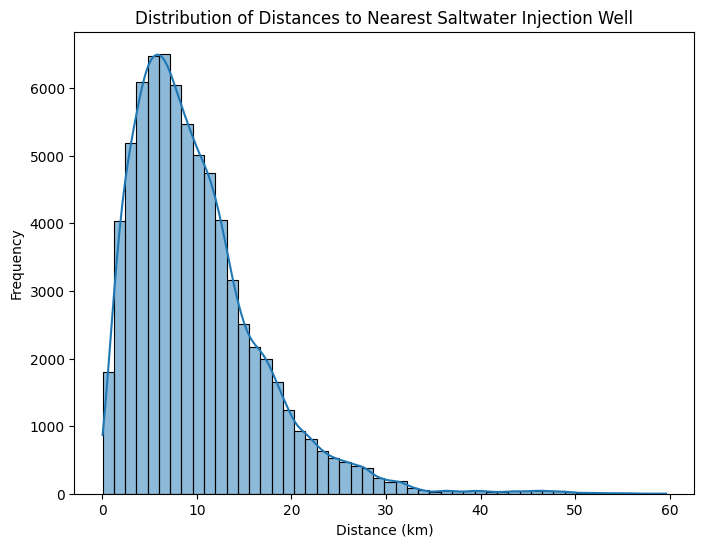

In [11]:
# Generate distribution plots for distances
import matplotlib.pyplot as plt
import seaborn as sns
nearest_2 = nearest_swiw_df[nearest_swiw_df['Nearest_SWIW_km'] < 60]

plt.figure(figsize=(8, 6))
sns.histplot(nearest_2['Nearest_SWIW_km'], bins=50, kde=True)
plt.title('Distribution of Distances to Nearest Saltwater Injection Well')
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.show()

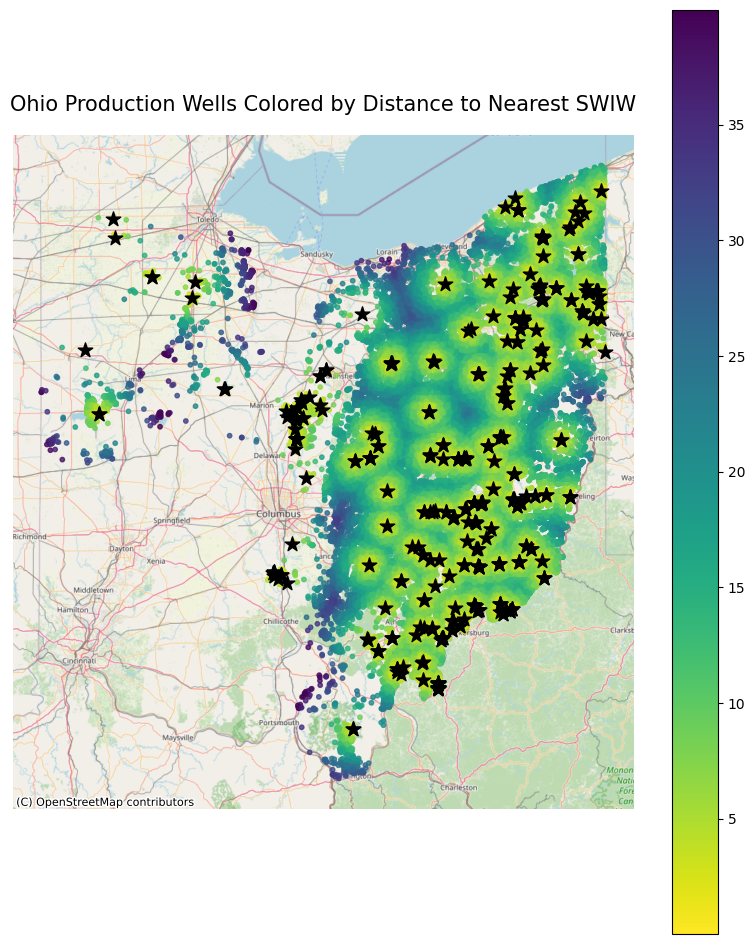

In [44]:
import contextily as ctx

really_nearest = nearest_swiw_df[nearest_swiw_df['Nearest_SWIW_km'] < 40]

prod_gdf = gpd.GeoDataFrame(
    really_nearest,
    geometry=gpd.points_from_xy(really_nearest["WELL LONGITUDE"], really_nearest["WELL LATITUDE"]),
    crs="EPSG:4326"
)

swiw_gdf = gpd.GeoDataFrame(
    swiw_df,
    geometry=gpd.points_from_xy(swiw_df["WH_LONG"], swiw_df["WH_LAT"]),
    crs="EPSG:4326"
)

prod_gdf = prod_gdf.to_crs(epsg=3857)
swiw_gdf = swiw_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 12))

prod_gdf.plot(
    ax=ax,
    column="Nearest_SWIW_km",
    cmap="viridis_r",
    markersize=10,
    alpha=0.8,
    legend=True
)

swiw_gdf.plot(
    ax=ax,
    color="black",
    marker="*",
    markersize=120,
    label="SWIW"
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Ohio Production Wells Colored by Distance to Nearest SWIW", fontsize=15)
ax.set_axis_off()

plt.show()

In [52]:
# Basic Regression - Distance to Nearest Saltwater Injection Well vs. Well Production

import statsmodels.api as sm
distance_data = pd.read_csv('../data/distance/well_to_nearest_saltwater_updated.csv')
production_data = pd.read_csv('../data/final/annual_production_final.csv')
regression_data = pd.merge(distance_data, production_data, left_on='API WELL NUMBER', right_on='API Number')

regression_data = regression_data[(regression_data['Production Year'] == 2024) & (regression_data['Quarter (1, 2, 3, 4, n/a)'].isna()) & (regression_data['Gas (Mcf)'] > 0) & (regression_data['Gas (Mcf)'] < 10000)]

X = regression_data['Nearest_SWIW_km']
y = regression_data['Gas (Mcf)']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              Gas (Mcf)   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.07431
Date:                Sat, 15 Nov 2025   Prob (F-statistic):              0.785
Time:                        16:06:24   Log-Likelihood:            -1.8624e+05
No. Observations:               21827   AIC:                         3.725e+05
Df Residuals:                   21825   BIC:                         3.725e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             958.4516     15.501     

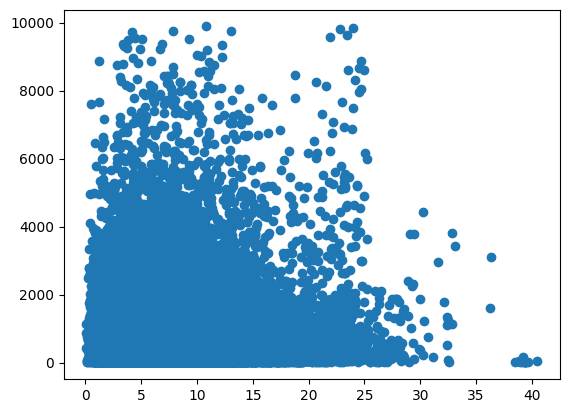

In [53]:
plt.scatter(regression_data['Nearest_SWIW_km'], regression_data['Gas (Mcf)'])

In [54]:
# Same thing for oil production
distance_data = pd.read_csv('../data/distance/well_to_nearest_saltwater_updated.csv')
production_data = pd.read_csv('../data/final/annual_production_final.csv')
regression_data = pd.merge(distance_data, production_data, left_on='API WELL NUMBER', right_on='API Number')

regression_data = regression_data[(regression_data['Production Year'] == 2024) & (regression_data['Quarter (1, 2, 3, 4, n/a)'].isna()) & (regression_data['Oil (Bbls)'] > 0)]

X = regression_data['Nearest_SWIW_km']
y = regression_data['Oil (Bbls)']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Oil (Bbls)   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     11.16
Date:                Sat, 15 Nov 2025   Prob (F-statistic):           0.000836
Time:                        16:06:40   Log-Likelihood:                -92979.
No. Observations:               13594   AIC:                         1.860e+05
Df Residuals:                   13592   BIC:                         1.860e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             111.0484      3.381     

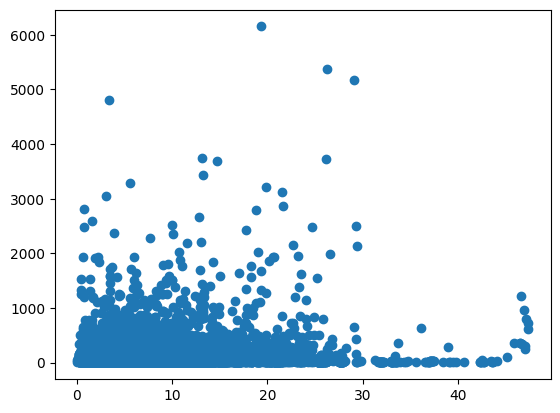

In [55]:
plt.scatter(regression_data['Nearest_SWIW_km'], regression_data['Oil (Bbls)'])

In [86]:
from datetime import datetime
import statsmodels.formula.api as smf

well_info = pd.read_csv("../data/final/well_information_final.csv")
dist_info = pd.read_csv("../data/distance/well_to_nearest_saltwater_updated.csv")
prod = pd.read_csv("../data/final/quarterly_production_final.csv")
permits = pd.read_csv("../data/final/permit_plug_list_final.csv")

swiw = permits[
    (permits['PROP_WLTYPE'] == 'SW_R') |
    (permits['APP_TYP_Description'] == 'Convert SWIW') |
    (permits['APP_TYP_Description'] == 'Salt Water Injection Well New Well')
].copy()
swiw = swiw[["API_WELLNO", "DT_APP_ISSUED", "WH_LAT", "WH_LONG"]]
swiw.rename(columns={"API_WELLNO": "API"}, inplace=True)
swiw["permit_date"] = pd.to_datetime(swiw["DT_APP_ISSUED"], errors="coerce")

dist_info.rename(columns={"API WELL NUMBER": "API"}, inplace=True)
prod.rename(columns={"API Number": "API"}, inplace=True)

prod = prod.merge(dist_info, on="API", how="left")

prod = prod.merge(
    swiw[["API", "permit_date"]].rename(columns={"API": "Nearest_SWIW_API"}),
    on="Nearest_SWIW_API", how="left"
)

# Take this out and switch to annual and quarterly if we want to consider both
prod = prod[prod['Quarter (1, 2, 3, 4, n/a)'].isin([1,2,3,4])]

def row_to_qdate(row):
    yr = row["Production Year"]
    q = row["Quarter (1, 2, 3, 4, n/a)"]
    if str(q).lower() in ["na", "n/a", None]:
        # annual → assign Q4
        return pd.Period(f"{yr}Q4").to_timestamp('Q')
    else:
        return pd.Period(f"{yr}Q{int(q)}").to_timestamp('Q')

prod["qdate"] = prod.apply(row_to_qdate, axis=1)

prod["rel_days"] = (prod["qdate"] - prod["permit_date"]).dt.days
prod["rel_quarters"] = (prod["rel_days"] / 90).round().astype("Int64")
prod = prod[~prod['rel_quarters'].isna()]
prod["post"] = (prod["rel_quarters"] >= 0).astype(int)

prod["inv_dist"] = 1 / (prod["Nearest_SWIW_km"] + 0.1)  # avoid div by zero
prod["log_inv_dist"] = np.log(prod["inv_dist"])

# prod = prod[prod['Nearest_SWIW_km'] <= 3]

model = smf.ols(
    formula="""
        Q("Oil (Bbls)") ~ post * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=prod
).fit(cov_type="cluster", cov_kwds={"groups": prod["API"]})

print(model.summary())

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3466, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


                            OLS Regression Results                            
Dep. Variable:        Q("Oil (Bbls)")   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                -9.591e-06
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               1.00
Time:                        14:06:51   Log-Likelihood:            -1.7885e+06
No. Observations:              177756   AIC:                         3.584e+06
Df Residuals:                  174290   BIC:                         3.619e+06
Df Model:                        3465                                         
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [87]:
prod_fil = prod[prod['Nearest_SWIW_km'] <= 3]

model = smf.ols(
    formula="""
        Q("Oil (Bbls)") ~ post * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=prod_fil
).fit(cov_type="cluster", cov_kwds={"groups": prod_fil["API"]})

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Q("Oil (Bbls)")   R-squared:                       0.430
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                 3.312e+04
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        14:10:42   Log-Likelihood:            -1.4040e+05
No. Observations:               13918   AIC:                         2.814e+05
Df Residuals:                   13620   BIC:                         2.836e+05
Df Model:                         297                                         
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 298, but rank is 51
  warnings.warn('covariance of constraints does not have full '


In [ ]:
panel = prod[(prod["rel_quarters"] >= -12) & (prod["rel_quarters"] <= 12)].copy()
for k in range(-12, 13):
    panel[f"event_{k}"] = (panel["rel_quarters"] == k).astype(int)

event_cols = [f"event_{k}" for k in range(-12, 13) if k != -1]

formula = "Q('Oil (Bbls)') ~ " + " + ".join(event_cols) + " + C(API) + C(qdate)"

event_model = smf.ols(
    formula=formula,
    data=panel
).fit(cov_type="cluster", cov_kwds={"groups": panel["API"]})

In [ ]:
# Repeat for Gas

model = smf.ols(
    formula="""
        Q("Gas (Mcf)") ~ post * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=prod
).fit(cov_type="cluster", cov_kwds={"groups": prod["API"]})

print(model.summary())

In [3]:
from datetime import datetime
import statsmodels.formula.api as smf

well_info = pd.read_csv("../data/final/well_information_final.csv")
dist_info = pd.read_csv("../data/distance/well_to_nearest_saltwater_updated.csv")
prod = pd.read_csv("../data/final/annual_production_final.csv")
permits = pd.read_csv("../data/final/permit_plug_list_final.csv")

swiw = permits[
    (permits['PROP_WLTYPE'] == 'SW_R') |
    (permits['APP_TYP_Description'] == 'Convert SWIW') |
    (permits['APP_TYP_Description'] == 'Salt Water Injection Well New Well')
].copy()
swiw = swiw[["API_WELLNO", "DT_APP_ISSUED", "WH_LAT", "WH_LONG"]]
swiw.rename(columns={"API_WELLNO": "API"}, inplace=True)
swiw["permit_date"] = pd.to_datetime(swiw["DT_APP_ISSUED"], errors="coerce")

dist_info.rename(columns={"API WELL NUMBER": "API"}, inplace=True)
prod.rename(columns={"API Number": "API"}, inplace=True)

prod = prod.merge(dist_info, on="API", how="left")

prod = prod[prod['Nearest_SWIW_km'] <= 3]

prod = prod.merge(
    swiw[["API", "permit_date"]].rename(columns={"API": "Nearest_SWIW_API"}),
    on="Nearest_SWIW_API", how="left"
)

# -----------------------------
#  ANNUAL PRODUCTION FILTERING
# -----------------------------
prod = prod[
    prod['Quarter (1, 2, 3, 4, n/a)'].isna() |
    (prod['Quarter (1, 2, 3, 4, n/a)'].astype(str).str.lower().isin(["na", "n/a"]))
]

outlier_wells = prod.loc[prod["Oil (Bbls)"] > 500, "API"].unique()
prod = prod[~prod["API"].isin(outlier_wells)].copy()

# -----------------------------
#  Map annual rows to Q4 dates
# -----------------------------
def row_to_qdate(row):
    yr = row["Production Year"]
    q = row["Quarter (1, 2, 3, 4, n/a)"]

    if pd.isna(q) or str(q).lower() in ["na", "n/a"]:
        return pd.Period(f"{yr}Q4").to_timestamp(how="end")
    else:
        return pd.Period(f"{yr}Q{int(q)}").to_timestamp(how="end")

prod["qdate"] = prod.apply(row_to_qdate, axis=1)

prod["rel_days"] = (prod["qdate"] - prod["permit_date"]).dt.days
prod["rel_quarters"] = (prod["rel_days"] / 90).round().astype("Int64")
prod = prod[~prod['rel_quarters'].isna()]
prod["post"] = (prod["rel_quarters"] >= 0).astype(int)
prod["post_lag_1"] = (prod["rel_quarters"] >= 4).astype(int)
prod["post_lag_2"] = (prod["rel_quarters"] >= 8).astype(int)
prod["post_lag_3"] = (prod["rel_quarters"] >= 12).astype(int)

prod["inv_dist"] = 1 / (prod["Nearest_SWIW_km"] + 0.1)  # avoid div by zero
prod["log_inv_dist"] = np.log(prod["inv_dist"])

pre_post_prod = prod.groupby(["API", "post"])["Oil (Bbls)"].sum().unstack(fill_value=0)
valid_wells = pre_post_prod[(pre_post_prod.get(0, 0) > 0) & (pre_post_prod.get(1, 0) > 0)].index
prod = prod[prod["API"].isin(valid_wells)].copy()

In [4]:
model_no_lag = smf.ols(
    formula=f"""
        Q("Oil (Bbls)") ~ post * log_inv_dist
        + C(API) + C(qdate)
    """,
    data=prod
).fit(cov_type="cluster", cov_kwds={"groups": prod["API"]})

print(model_no_lag.summary())

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1970, but rank is 1
  warnings.warn('covariance of constraints does not have full '
c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


                            OLS Regression Results                            
Dep. Variable:        Q("Oil (Bbls)")   R-squared:                       0.657
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                -1.785e-07
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               1.00
Time:                        23:30:18   Log-Likelihood:            -3.1402e+05
No. Observations:               59274   AIC:                         6.320e+05
Df Residuals:                   57304   BIC:                         6.497e+05
Df Model:                        1969                                         
Covariance Type:              cluster                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [154]:
lag_models = {}
for i in [1,2,3]:
    lag_years = i
    lag_quarters = lag_years*4

    lag_models[f"post_lag_{i}_model"] = smf.ols(
        formula=f"""
            Q("Oil (Bbls)") ~ post_lag_{i} * log_inv_dist
            + C(API) + C(qdate)
        """,
        data=prod
    ).fit(cov_type="cluster", cov_kwds={"groups": prod["API"]})

    print(lag_models[f"post_lag_{i}_model"].summary())

LinAlgError: SVD did not converge

In [162]:
import plotly.express as px
import pandas as pd
import numpy as np

# --- Aggregate production per well and compute difference ---
def aggregate_change(df, post_col):
    agg = df.groupby("API").agg(
        lat=("WELL LATITUDE", "first"),
        lon=("WELL LONGITUDE", "first"),
        pre=("Oil (Bbls)", lambda x: x[df.loc[x.index, post_col]==0].mean()),
        post=("Oil (Bbls)", lambda x: x[df.loc[x.index, post_col]==1].mean())
    ).reset_index()
    # Compute difference (after - before)
    agg["diff"] = agg["post"] - agg["pre"]
    return agg

# --- Datasets ---
well_post = aggregate_change(prod, "post")
well_post_lag = aggregate_change(prod, "post_lag_3")
well_post = well_post[well_post['diff'] < 20000]
well_post_lag = well_post_lag[well_post_lag['diff'] < 20000]


# --- Plot for immediate post ---
fig_post = px.scatter_mapbox(
    well_post,
    lat="lat",
    lon="lon",
    color="diff",
    color_continuous_scale="RdBu",
    hover_name="API",
    hover_data={"pre":True, "post":True, "diff":True},
    zoom=6,
    height=600,
    title="Production Change (After - Before) Post (Immediate)"
)
fig_post.update_layout(mapbox_style="open-street-map")
fig_post.show()

# --- Plot for lagged post ---
fig_post_lag = px.scatter_mapbox(
    well_post_lag,
    lat="lat",
    lon="lon",
    color="diff",
    color_continuous_scale="RdBu",
    hover_name="API",
    hover_data={"pre":True, "post":True, "diff":True},
    zoom=6,
    height=600,
    title="Production Change (After - Before) Post (Lagged)"
)
fig_post_lag.update_layout(mapbox_style="open-street-map")
fig_post_lag.show()


c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.

c:\Users\willf\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a f

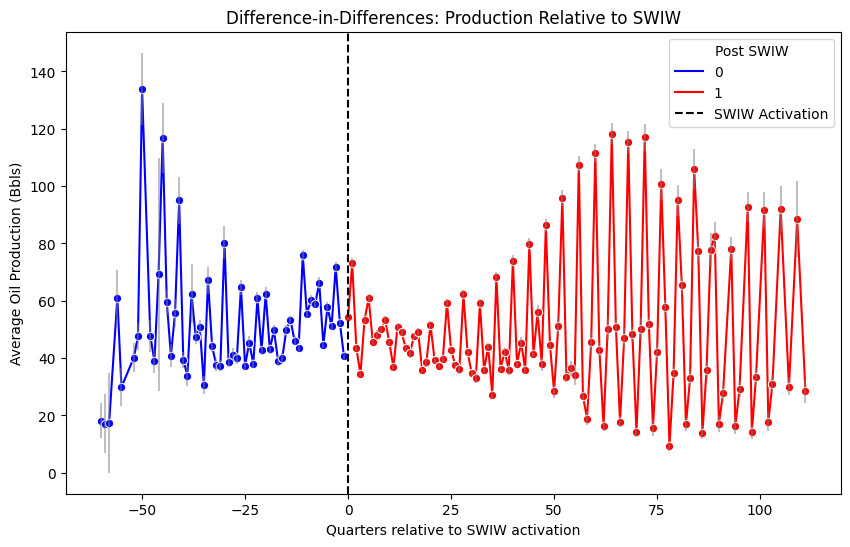

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate average production by relative quarter and post
agg = prod.groupby(["rel_quarters", "post"]).agg(
    avg_prod=("Oil (Bbls)", "mean"),
    std_prod=("Oil (Bbls)", "std"),
    count=("Oil (Bbls)", "count")
).reset_index()

agg["se"] = agg["std_prod"] / np.sqrt(agg["count"])

plt.figure(figsize=(10,6))
sns.lineplot(
    data=agg,
    x="rel_quarters",
    y="avg_prod",
    hue="post",
    marker="o",
    palette=["blue","red"]
)

# Add error bars for SE
for i,row in agg.iterrows():
    plt.errorbar(x=row["rel_quarters"], y=row["avg_prod"], yerr=row["se"], fmt='none', color='gray', alpha=0.5)

plt.axvline(0, color="black", linestyle="--", label="SWIW Activation")
plt.xlabel("Quarters relative to SWIW activation")
plt.ylabel("Average Oil Production (Bbls)")
plt.title("Difference-in-Differences: Production Relative to SWIW")
plt.legend(title="Post SWIW")
plt.show()

In [144]:
dist_range = np.linspace(prod["log_inv_dist"].min(), prod["log_inv_dist"].max(), 50)
effect = model.params["post_lag_1"] + model.params["post:log_inv_dist"] * dist_range

plt.figure(figsize=(8,5))
plt.plot(dist_range, effect, color="blue")
plt.xlabel("log(1 / Distance to SWIW)")
plt.ylabel("Estimated Treatment Effect")
plt.title("Effect of SWIW by Distance")
plt.show()

KeyError: 'post_lag_1'

In [97]:
from datetime import datetime
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS


# Load data
well_info = pd.read_csv("../data/final/well_information_final.csv")
dist_info = pd.read_csv("../data/distance/well_to_nearest_saltwater_updated.csv")
prod = pd.read_csv("../data/final/annual_production_final.csv")
permits = pd.read_csv("../data/final/permit_plug_list_final.csv")

# Identify SWIW wells
swiw = permits[
    (permits['PROP_WLTYPE'] == 'SW_R') |
    (permits['APP_TYP_Description'] == 'Convert SWIW') |
    (permits['APP_TYP_Description'] == 'Salt Water Injection Well New Well')
].copy()

swiw = swiw[["API_WELLNO", "DT_APP_ISSUED", "WH_LAT", "WH_LONG"]]
swiw.rename(columns={"API_WELLNO": "API"}, inplace=True)
swiw["permit_date"] = pd.to_datetime(swiw["DT_APP_ISSUED"], errors="coerce")

# Merge info
dist_info.rename(columns={"API WELL NUMBER": "API"}, inplace=True)
prod.rename(columns={"API Number": "API"}, inplace=True)

prod = prod.merge(dist_info, on="API", how="left")

prod = prod.merge(
    swiw[["API", "permit_date"]].rename(columns={"API": "Nearest_SWIW_API"}),
    on="Nearest_SWIW_API",
    how="left"
)

# -----------------------------
#  ANNUAL PRODUCTION FILTERING
# -----------------------------
prod = prod[
    prod['Quarter (1, 2, 3, 4, n/a)'].isna() |
    (prod['Quarter (1, 2, 3, 4, n/a)'].astype(str).str.lower().isin(["na", "n/a"]))
]

# -----------------------------
#  Map annual rows to Q4 dates
# -----------------------------
def row_to_qdate(row):
    yr = row["Production Year"]
    q = row["Quarter (1, 2, 3, 4, n/a)"]

    if pd.isna(q) or str(q).lower() in ["na", "n/a"]:
        return pd.Period(f"{yr}Q4").to_timestamp('Q')  # annual → Q4
    else:
        return pd.Period(f"{yr}Q{int(q)}").to_timestamp('Q')

prod["qdate"] = prod.apply(row_to_qdate, axis=1)

# Relative timing to SWIW activation
prod["rel_days"] = (prod["qdate"] - prod["permit_date"]).dt.days
prod["rel_quarters"] = (prod["rel_days"] / 90).round().astype("Int64")
prod = prod[~prod['rel_quarters'].isna()]
prod["post"] = (prod["rel_quarters"] >= 0).astype(int)

# Distance transformations
prod["inv_dist"] = 1 / (prod["Nearest_SWIW_km"] + 0.1)
prod["log_inv_dist"] = np.log(prod["inv_dist"])

# prod[prod['Nearest_SWIW_km'] <= 3]

# center log_inv_dist for interpretability
prod["log_inv_dist_c"] = prod["log_inv_dist"] - prod["log_inv_dist"].mean()
prod["post_log_inv_dist"] = prod["post"] * prod["log_inv_dist_c"]

# set panel index
prod = prod.set_index(["API", "qdate"])

# formula: include post and the time-varying interaction; omit the time-invariant log_inv_dist
model = PanelOLS.from_formula(
    'Q("Oil (Bbls)") ~ 1 + post + post_log_inv_dist + EntityEffects + TimeEffects',
    data=prod
)

res = model.fit(cov_type="clustered", cluster_entity=True)
print(res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        Q('Oil (Bbls)')   R-squared:                        0.0004
Estimator:                   PanelOLS   R-squared (Between):             -0.0008
No. Observations:             1063595   R-squared (Within):              -0.0013
Date:                Sun, Nov 23 2025   R-squared (Overall):             -0.0014
Time:                        14:51:09   Log-likelihood                -7.144e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      213.33
Entities:                       52422   P-value                           0.0000
Avg Obs:                       20.289   Distribution:               F(2,1011157)
Min Obs:                       1.0000                                           
Max Obs:                       208.00   F-statistic (robust):             96.318
                            

In [103]:
from datetime import datetime
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS


# Load data
well_info = pd.read_csv("../data/final/well_information_final.csv")
dist_info = pd.read_csv("../data/distance/well_to_nearest_saltwater_updated.csv")
prod = pd.read_csv("../data/final/annual_production_final.csv")
permits = pd.read_csv("../data/final/permit_plug_list_final.csv")

# Identify SWIW wells
swiw = permits[
    (permits['PROP_WLTYPE'] == 'SW_R') |
    (permits['APP_TYP_Description'] == 'Convert SWIW') |
    (permits['APP_TYP_Description'] == 'Salt Water Injection Well New Well')
].copy()

swiw = swiw[["API_WELLNO", "DT_APP_ISSUED", "WH_LAT", "WH_LONG"]]
swiw.rename(columns={"API_WELLNO": "API"}, inplace=True)
swiw["permit_date"] = pd.to_datetime(swiw["DT_APP_ISSUED"], errors="coerce")

# Merge info
dist_info.rename(columns={"API WELL NUMBER": "API"}, inplace=True)
prod.rename(columns={"API Number": "API"}, inplace=True)

prod = prod.merge(dist_info, on="API", how="left")

prod = prod.merge(
    swiw[["API", "permit_date"]].rename(columns={"API": "Nearest_SWIW_API"}),
    on="Nearest_SWIW_API",
    how="left"
)

# -----------------------------
#  ANNUAL PRODUCTION FILTERING
# -----------------------------
prod = prod[
    prod['Quarter (1, 2, 3, 4, n/a)'].isna() |
    (prod['Quarter (1, 2, 3, 4, n/a)'].astype(str).str.lower().isin(["na", "n/a"]))
]

# -----------------------------
#  Map annual rows to Q4 dates
# -----------------------------
def row_to_qdate(row):
    yr = row["Production Year"]
    q = row["Quarter (1, 2, 3, 4, n/a)"]

    if pd.isna(q) or str(q).lower() in ["na", "n/a"]:
        return pd.Period(f"{yr}Q4").to_timestamp('Q')  # annual → Q4
    else:
        return pd.Period(f"{yr}Q{int(q)}").to_timestamp('Q')

prod["qdate"] = prod.apply(row_to_qdate, axis=1)

# Relative timing to SWIW activation
prod["rel_days"] = (prod["qdate"] - prod["permit_date"]).dt.days
prod["rel_quarters"] = (prod["rel_days"] / 90).round().astype("Int64")
prod = prod[~prod['rel_quarters'].isna()]
prod["post"] = (prod["rel_quarters"] >= 0).astype(int)

# Distance transformations
prod["inv_dist"] = 1 / (prod["Nearest_SWIW_km"] + 0.1)
prod["log_inv_dist"] = np.log(prod["inv_dist"])

prod = prod[prod['Nearest_SWIW_km'] <= 3]

prod = (
    prod.groupby("API")
        .filter(lambda g: g["Oil (Bbls)"].mean() < 400)
)

# center log_inv_dist for interpretability
prod["log_inv_dist_c"] = prod["log_inv_dist"] - prod["log_inv_dist"].mean()
prod["post_log_inv_dist"] = prod["post"] * prod["log_inv_dist_c"]

# set panel index
prod = prod.set_index(["API", "qdate"])

# formula: include post and the time-varying interaction; omit the time-invariant log_inv_dist
model = PanelOLS.from_formula(
    'Q("Oil (Bbls)") ~ 1 + post + post_log_inv_dist + EntityEffects + TimeEffects',
    data=prod
)

res = model.fit(cov_type="clustered", cluster_entity=True)
print(res.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:        Q('Oil (Bbls)')   R-squared:                     4.529e-05
Estimator:                   PanelOLS   R-squared (Between):             -0.0005
No. Observations:              143988   R-squared (Within):              -0.0019
Date:                Tue, Dec 02 2025   R-squared (Overall):           8.641e-05
Time:                        19:17:24   Log-likelihood                -7.882e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.1091
Entities:                        6669   P-value                           0.0446
Avg Obs:                       21.591   Distribution:                F(2,137303)
Min Obs:                       1.0000                                           
Max Obs:                       208.00   F-statistic (robust):             0.5593
                            

In [105]:
from datetime import datetime
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

# -------------------------------------------------
# your entire data loading / cleaning code unchanged
# -------------------------------------------------

well_info = pd.read_csv("../data/final/well_information_final.csv")
dist_info = pd.read_csv("../data/distance/well_to_nearest_saltwater_updated.csv")
prod = pd.read_csv("../data/final/annual_production_final.csv")
permits = pd.read_csv("../data/final/permit_plug_list_final.csv")

swiw = permits[
    (permits['PROP_WLTYPE'] == 'SW_R') |
    (permits['APP_TYP_Description'] == 'Convert SWIW') |
    (permits['APP_TYP_Description'] == 'Salt Water Injection Well New Well')
].copy()

swiw = swiw[["API_WELLNO", "DT_APP_ISSUED", "WH_LAT", "WH_LONG"]]
swiw.rename(columns={"API_WELLNO": "API"}, inplace=True)
swiw["permit_date"] = pd.to_datetime(swiw["DT_APP_ISSUED"], errors="coerce")

dist_info.rename(columns={"API WELL NUMBER": "API"}, inplace=True)
prod.rename(columns={"API Number": "API"}, inplace=True)

prod = prod.merge(dist_info, on="API", how="left")

prod = prod.merge(
    swiw[["API", "permit_date"]].rename(columns={"API": "Nearest_SWIW_API"}),
    on="Nearest_SWIW_API",
    how="left"
)

prod = prod[
    prod['Quarter (1, 2, 3, 4, n/a)'].isna() |
    (prod['Quarter (1, 2, 3, 4, n/a)'].astype(str).str.lower().isin(["na", "n/a"]))
]

def row_to_qdate(row):
    yr = row["Production Year"]
    q = row["Quarter (1, 2, 3, 4, n/a)"]
    if pd.isna(q) or str(q).lower() in ["na", "n/a"]:
        return pd.Period(f"{yr}Q4").to_timestamp('Q')
    else:
        return pd.Period(f"{yr}Q{int(q)}").to_timestamp('Q')

prod["qdate"] = prod.apply(row_to_qdate, axis=1)
prod["rel_days"] = (prod["qdate"] - prod["permit_date"]).dt.days
prod["rel_quarters"] = (prod["rel_days"] / 90).round().astype("Int64")
prod = prod[~prod['rel_quarters'].isna()]
prod["post"] = (prod["rel_quarters"] >= 0).astype(int)

prod["inv_dist"] = 1 / (prod["Nearest_SWIW_km"] + 0.1)
prod["log_inv_dist"] = np.log(prod["inv_dist"])

prod = prod[prod['Nearest_SWIW_km'] <= 3]

prod = (
    prod.groupby("API")
        .filter(lambda g: g["Oil (Bbls)"].mean() < 400)
)

prod["log_inv_dist_c"] = prod["log_inv_dist"] - prod["log_inv_dist"].mean()
prod["post_log_inv_dist"] = prod["post"] * prod["log_inv_dist_c"]

prod = prod.set_index(["API", "qdate"])

# -------------------------------------------------
# NEW SECTION: automatic lag search with AIC
# -------------------------------------------------

MAX_LAGS = 6
fit_scores = {}

for L in range(MAX_LAGS + 1):

    # generate lags
    for k in range(1, L + 1):
        prod[f"post_l{k}"] = prod.groupby(level=0)["post"].shift(k)
        prod[f"post_log_inv_dist_l{k}"] = prod.groupby(level=0)["post_log_inv_dist"].shift(k)

    lag_vars = [f"post_l{k}" for k in range(1, L + 1)] + \
               [f"post_log_inv_dist_l{k}" for k in range(1, L + 1)]

    prod_lagged = prod.dropna(subset=lag_vars) if L > 0 else prod.copy()

    lag_terms = " + ".join(
        ["post_l" + str(k) for k in range(1, L + 1)] +
        ["post_log_inv_dist_l" + str(k) for k in range(1, L + 1)]
    )

    formula = (
        'Q("Oil (Bbls)") ~ 1 + post + post_log_inv_dist'
        + ("" if L == 0 else " + " + lag_terms)
        + " + EntityEffects + TimeEffects"
    )

    model = PanelOLS.from_formula(formula, data=prod_lagged)
    result = model.fit(cov_type="clustered", cluster_entity=True)

    # USE ADJUSTED WITHIN R-SQUARED
    score = result.rsquared_adj
    fit_scores[L] = score

    print(f"Lag {L}: Adj. R² (within) = {score}")

# best lag = **max** adjusted R²
best_L = max(fit_scores, key=fit_scores.get)
print(f"\nBest lag length based on adjusted within R²: {best_L}")


# -------------------------------------------------
# Refit final model using best lag length
# -------------------------------------------------

L = best_L

# regenerate best-lag variables cleanly
for k in range(1, L + 1):
    prod[f"post_l{k}"] = prod.groupby(level=0)["post"].shift(k)
    prod[f"post_log_inv_dist_l{k}"] = prod.groupby(level=0)["post_log_inv_dist"].shift(k)

if L > 0:
    prod_final = prod.dropna(subset=[f"post_l{k}" for k in range(1, L + 1)])
else:
    prod_final = prod.copy()

lag_terms = " + ".join(
    ["post_l" + str(k) for k in range(1, L + 1)] +
    ["post_log_inv_dist_l" + str(k) for k in range(1, L + 1)]
)

final_formula = (
    'Q("Oil (Bbls)") ~ 1 + post + post_log_inv_dist'
    + ("" if L == 0 else " + " + lag_terms)
    + " + EntityEffects + TimeEffects"
)

final_model = PanelOLS.from_formula(final_formula, data=prod_final)
final_res = final_model.fit(cov_type="clustered", cluster_entity=True)

print("\n=== FINAL MODEL ===")
print(final_res.summary)


AttributeError: 'PanelEffectsResults' object has no attribute 'rsquared_adj'

In [101]:
prod.shape

(147698, 37)

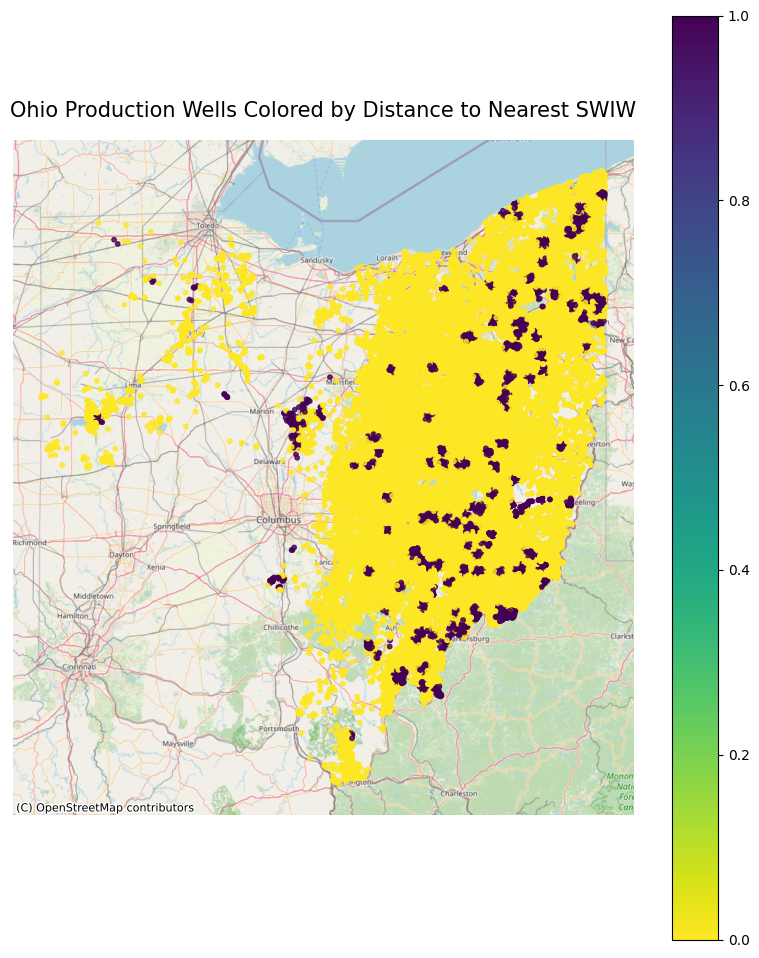

In [80]:
import contextily as ctx

really_nearest = nearest_swiw_df[nearest_swiw_df['Nearest_SWIW_km'] < 40]

prod_gdf = gpd.GeoDataFrame(
    really_nearest,
    geometry=gpd.points_from_xy(really_nearest["WELL LONGITUDE"], really_nearest["WELL LATITUDE"]),
    crs="EPSG:4326"
)

prod_gdf['5K_OR_LESS'] = np.where(prod_gdf['Nearest_SWIW_km'] <= 3,1,0)

swiw_gdf = gpd.GeoDataFrame(
    swiw_df,
    geometry=gpd.points_from_xy(swiw_df["WH_LONG"], swiw_df["WH_LAT"]),
    crs="EPSG:4326"
)

prod_gdf = prod_gdf.to_crs(epsg=3857)
swiw_gdf = swiw_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 12))

prod_gdf.plot(
    ax=ax,
    column="5K_OR_LESS",
    cmap="viridis_r",
    markersize=10,
    alpha=0.8,
    legend=True
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Ohio Production Wells Colored by Distance to Nearest SWIW", fontsize=15)
ax.set_axis_off()

plt.show()

In [81]:
print(prod_gdf[prod_gdf['5K_OR_LESS'] == 1].shape)
print(prod_gdf[prod_gdf['5K_OR_LESS'] == 0].shape)

(8401, 21)
(64841, 21)


In [82]:
import pandas as pd
import numpy as np
from pygam import LinearGAM, s, f
from dateutil.relativedelta import relativedelta

wellinfo = pd.read_csv("../data/final/well_information_final.csv")
distance = pd.read_csv("../data/distance/well_to_nearest_saltwater_updated.csv")
prod = pd.read_csv("../data/final/quarterly_production_final.csv")
perm = pd.read_csv("../data/final/permit_plug_list_final.csv")

prod['QUARTER'] = prod['Quarter (1, 2, 3, 4, n/a)']

# Standardize column names
distance.columns = [c.strip().upper().replace(" ", "_") for c in distance.columns]
prod.columns = [c.strip().upper().replace(" ", "_") for c in prod.columns]
wellinfo.columns = [c.strip().upper().replace(" ", "_") for c in wellinfo.columns]
perm.columns = [c.strip().upper().replace(" ", "_") for c in perm.columns]

swiw = perm[
    (perm['PROP_WLTYPE'] == 'SW_R') |
    (perm['APP_TYP_DESCRIPTION'] == 'Convert SWIW') |
    (perm['APP_TYP_DESCRIPTION'] == 'Salt Water Injection Well New Well')
].copy()

# Extract SWIW activation date
swiw["DT_APP_ISSUED"] = pd.to_datetime(swiw["DT_APP_ISSUED"], errors="coerce")
swiw = swiw[["API_WELLNO", "DT_APP_ISSUED"]]
swiw = swiw.groupby("API_WELLNO", as_index=False).min()

distance = distance.rename(columns={"API_WELL_NUMBER": "API"})
swiw = swiw.rename(columns={"API_WELLNO": "SWIW_API"})

distance = distance.rename(columns={"NEAREST_SWIW_API": "SWIW_API"})

dist_merge = distance.merge(swiw, on="SWIW_API", how="left")
dist_merge = dist_merge.rename(columns={"DT_APP_ISSUED": "NEAREST_SWIW_DATE"})

prod["QUARTER"] = prod["QUARTER"].replace("n/a", np.nan)
prod["PRODUCTION_YEAR"] = prod["PRODUCTION_YEAR"].astype(int)

prod = prod[prod['QUARTER'].isin([1,2,3,4])]

def make_date(row):
    if pd.isna(row["QUARTER"]):
        return pd.to_datetime(f"{int(row['PRODUCTION_YEAR'])}-07-01")
    else:
        q = int(row["QUARTER"])
        month = {1:1, 2:4, 3:7, 4:10}[q]
        return pd.to_datetime(f"{int(row['PRODUCTION_YEAR'])}-{month}-01")

prod["DATE"] = prod.apply(make_date, axis=1)

prod = prod.rename(columns={"API_NUMBER": "API"})

df = (
    prod.merge(dist_merge, on="API", how="left")
)

df = df[df['NEAREST_SWIW_KM'] <= 3]

df["NEAREST_SWIW_DATE"] = pd.to_datetime(df["NEAREST_SWIW_DATE"], errors="coerce")
df["DATE"] = pd.to_datetime(df["DATE"])

df["SWIW_ACTIVE"] = (df["DATE"] >= df["NEAREST_SWIW_DATE"]).astype(int)

df = df.sort_values("DATE")
df["T_INDEX"] = df["DATE"].rank(method="dense")

df = df.dropna(subset=["NEAREST_SWIW_KM", "OIL_(BBLS)", "T_INDEX"])

df["OIL"] = df["OIL_(BBLS)"]

# Encode categorical variables
df["API_CAT"] = df["API"].astype("category").cat.codes
df["FORMATION_CAT"] = df["PRODUCING_FORMATION"].astype("category").cat.codes
df["COUNTY_CAT"] = df["COUNTY"].astype("category").cat.codes
df["TREAT_TIME"] = df["T_INDEX"] * df["SWIW_ACTIVE"]

# Final model matrix
X = df[[
    "T_INDEX",
    "NEAREST_SWIW_KM",
    "TREAT_TIME",
    "FORMATION_CAT",
    "COUNTY_CAT"
]].values

y = df["OIL"].values

print("Fitting GAM... (this may take a few minutes)")

gam = LinearGAM(
    s(0)               # baseline time smooth
    + s(1)             # smooth distance effect
    + s(2)             # smooth treatment effect: time × SWIW_ACTIVE
    + f(3)    # formation random effect
    + f(4)    # county random effect
).fit(X, y)

print("Done!")

print("\nGAM model summary:")
print(gam.summary())


Fitting GAM... (this may take a few minutes)
Done!

GAM model summary:
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     52.3653
Link Function:                     IdentityLink Log Likelihood:                               -141710.7331
Number of Samples:                         7495 AIC:                                           283528.1968
                                                AICc:                                          283528.9766
                                                GCV:                                         65730829.4444
                                                Scale:                                       64904712.2919
                                                Pseudo R-Squared:        

C:\Users\willf\AppData\Local\Temp\ipykernel_12536\3727751651.py:103: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


Residualized OIL after removing well, formation, and county effects
GAM fitted on residuals
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     42.0071
Link Function:                     IdentityLink Log Likelihood:                              -1938804.6779
Number of Samples:                       106052 AIC:                                          3877695.3698
                                                AICc:                                         3877695.4055
                                                GCV:                                         34740491.7899
                                                Scale:                                       34715723.4714
                                                Pseu

C:\Users\willf\AppData\Local\Temp\ipykernel_12536\1559681277.py:41: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


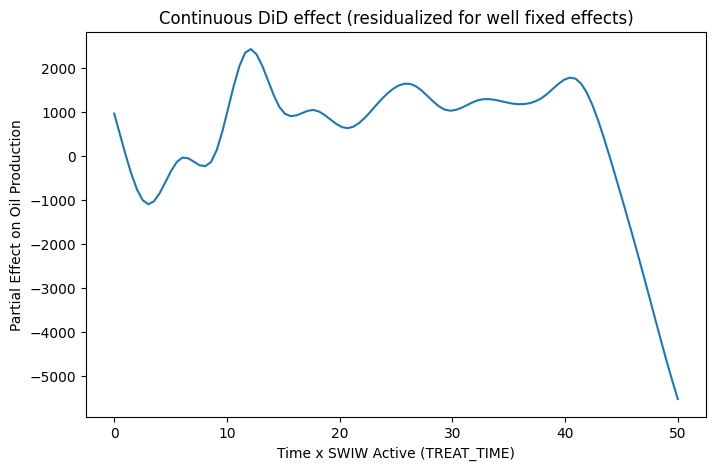

In [72]:
import pandas as pd
import numpy as np
from pygam import LinearGAM, s, f
import statsmodels.api as sm

# -------------------------
# Step 1: Residualize out well fixed effects
# -------------------------

# API dummies
api_dummies = pd.get_dummies(df['API'], drop_first=True)

# Optionally include formation/county as controls
formation_dummies = pd.get_dummies(df['FORMATION_CAT'], drop_first=True)
county_dummies = pd.get_dummies(df['COUNTY_CAT'], drop_first=True)

# Combine
X_fe = pd.concat([api_dummies, formation_dummies, county_dummies], axis=1)
y = df['OIL']

# Fit linear model to remove well-level (API) effects
fe_model = sm.OLS(y, X_fe).fit()
df['OIL_resid'] = fe_model.resid

print("Residualized OIL after removing well, formation, and county effects")

# -------------------------
# Step 2: Fit GAM on residuals
# -------------------------

X_gam = df[["T_INDEX", "NEAREST_SWIW_KM", "TREAT_TIME"]].values
y_gam = df["OIL_resid"].values

gam = LinearGAM(
    s(0) +  # smooth time trend
    s(1) +  # smooth distance
    s(2)    # continuous DiD effect
).fit(X_gam, y_gam)

print("GAM fitted on residuals")
print(gam.summary())

# -------------------------
# Step 3: Plot continuous DiD effect
# -------------------------
import matplotlib.pyplot as plt

XX = gam.generate_X_grid(term=2)
plt.figure(figsize=(8,5))
plt.plot(XX[:,2], gam.partial_dependence(term=2, X=XX))
plt.xlabel("Time x SWIW Active (TREAT_TIME)")
plt.ylabel("Partial Effect on Oil Production")
plt.title("Continuous DiD effect (residualized for well fixed effects)")
plt.show()
